test CaO-MnO

ref - Wu, P., Eriksson, G., Pelton, A.D., 1993. Critical Evaluation and Optimization of the Thermodynamic Properties and Phase Diagrams of the CaO–FeO, CaO–MgO, CaO–MnO, FeO–MgO, FeO–MnO, and MgO–MnO Systems. Journal of the American Ceramic Society 76, 2065–2075. https://doi.org/10.1111/j.1151-2916.1993.tb08334.x

# Solid

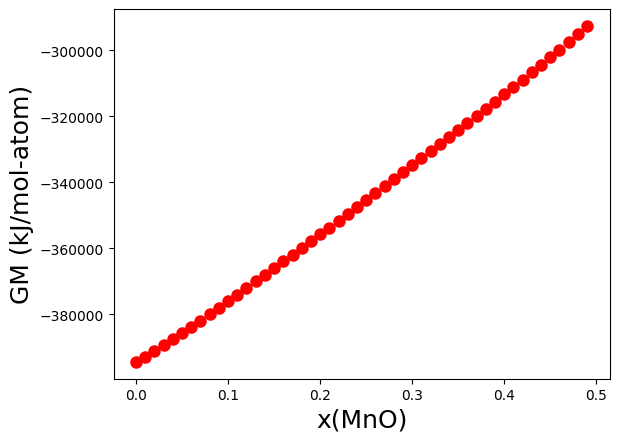

In [1]:
import os

os.environ["SETUPTOOLS_SCM_PRETEND_VERSION_FOR_PYCALPHAD"] = "0.11.1"

from pycalphad import Database, equilibrium, variables as v
import numpy as np
import matplotlib.pyplot as plt

dbf = Database("CaO-MnO.xml")
comps = ["CA", "MN", "O"]
phases = ["SOLID"]
conds = {
    v.N: 1,
    v.P: 101325,
    v.T: 1800,
    v.X("MN"): (0.0001, 0.49999, 0.01),
    v.X("O"): (0.5),
}

eq_1 = equilibrium(
    dbf,
    comps,
    phases,
    conds,
    verbose=False,
    calc_opts={"pdens": 2000},
    output=["SM", "HM", "G"],
)

comp_Mn = np.squeeze(eq_1.X.sel(component="MN").values)
X_Mn = np.array([i[0] for i in comp_Mn])

CalcGM = np.squeeze(eq_1.GM.values)
ax = plt.gca()
ax.plot(X_Mn, CalcGM, "ro", ms=8, label="PyCalphad")
ax.set_ylabel("GM (kJ/mol-atom)", fontsize=18)
ax.set_xlabel("x(MnO)", fontsize=18)
plt.show()

In [2]:
# import pandas as pd

# df = pd.DataFrame({"X_Mn": X_Mn, "CalcGM": CalcGM})

# output_path = "CaO_MnO_2500K_solid_PyCalphad.xlsx"
# df.to_excel(output_path, index=False)
# print(f"Save data to: {output_path}")

# liquid

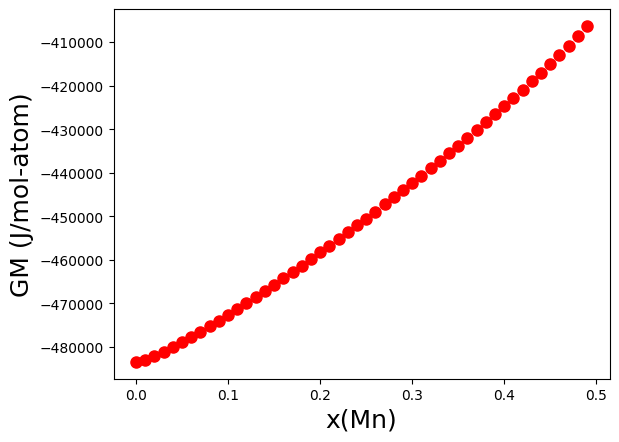

In [3]:
import os

from pycalphad import Database, equilibrium, variables as v
import numpy as np
import matplotlib.pyplot as plt

from pycalphad.models.model_mqmqa import ModelMQMQA

dbf = Database("CaO-MnO.xml")
comps = ["CA", "MN", "O"]
phases = ["LIQUID#2"]
conds = {
    v.N: 1,
    v.P: 101325,
    v.T: 3000,
    v.X("MN"): (0.0001, 0.49999, 0.01),
    v.X("O"): (0.5),
}

eq_2 = equilibrium(
    dbf,
    comps,
    phases,
    conds,
    verbose=False,
    model={"LIQUID#2": ModelMQMQA},
    calc_opts={"pdens": 1000},
    output=["SM", "HM", "G"],
)

comp_Mn = np.squeeze(eq_2.X.sel(component="MN").values)
X_Mn = np.arange(0.0001, 0.49999, 0.01)
CalcGM = np.squeeze(eq_2.GM.values)
ax = plt.gca()
ax.plot(X_Mn, CalcGM, "ro", ms=8, label="PyCalphad")
ax.set_ylabel("GM (J/mol-atom)", fontsize=18)
ax.set_xlabel("x(Mn)", fontsize=18)
plt.show()

In [4]:
# import pandas as pd

# df = pd.DataFrame({"X_Mn": X_Mn, "CalcGM": CalcGM})

# output_path = "CaO_MnO_3000K_liquid_PyCalphad_MQMQA_d6.xlsx"
# df.to_excel(output_path, index=False)
# print(f"Save data to: {output_path}")

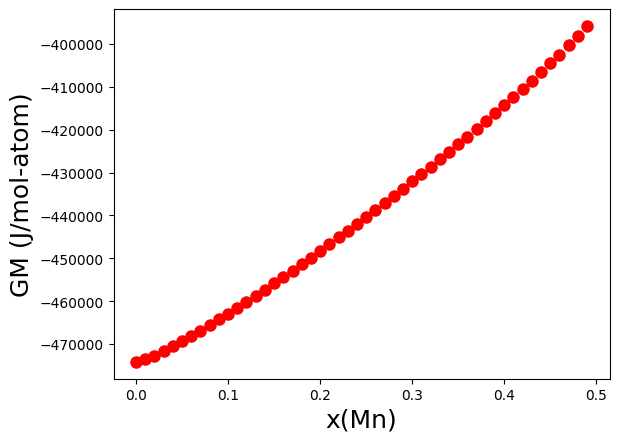

In [5]:
import os

os.environ["SETUPTOOLS_SCM_PRETEND_VERSION_FOR_PYCALPHAD"] = "0.11.1"

from pycalphad import Database, equilibrium, variables as v
import numpy as np
import matplotlib.pyplot as plt

from pycalphad.models.model_mqmqa import ModelMQMQA

T = 2900

dbf = Database("CaO-MnO.xml")
comps = ["CA", "MN", "O"]
phases = ["LIQUID#2", "SOLID"]
conds = {
    v.N: 1,
    v.P: 101325,
    v.T: T,
    v.X("MN"): (0.0001, 0.49999, 0.01),
    v.X("O"): (0.5),
}

eq_3 = equilibrium(
    dbf,
    comps,
    phases,
    conds,
    verbose=False,
    model={"LIQUID": ModelMQMQA},
    calc_opts={"pdens": 2000},
    output=["SM", "HM", "G"],
)

comp_Mn = np.squeeze(eq_3.X.sel(component="MN").values)
# X_Mn = np.array([i[0] for i in comp_Mn])
X_Mn = np.arange(0.0001, 0.49999, 0.01)
CalcGM = np.squeeze(eq_3.GM.values)
ax = plt.gca()
ax.plot(X_Mn, CalcGM, "ro", ms=8, label="PyCalphad")
ax.set_ylabel("GM (J/mol-atom)", fontsize=18)
ax.set_xlabel("x(Mn)", fontsize=18)
plt.show()